In [3]:
import pandas as pd
import numpy as np
import re
import string
import joblib


import nltk
from nltk.corpus import stopwords


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

nltk.download('stopwords')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pardhu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 2. Load Dataset

In [2]:
df = pd.read_csv("../data/all_tickets_processed_improved_v3.csv")

print("Dataset Loaded Successfully!")
print(df.shape)

Dataset Loaded Successfully!
(47837, 2)


# 3. Explore Dataset

In [6]:
print(df.columns)

df.head()

Index(['Document', 'Topic_group'], dtype='object')


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


# 4. Dataset Overview

In [7]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nCategory distribution:")
print(df["Topic_group"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB

Missing values:
Document       0
Topic_group    0
dtype: int64

Category distribution:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


# 5. Clean Dataset

In [8]:
df = df.dropna()

df["Document"] = df["Document"].astype(str)
df["Topic_group"] = df["Topic_group"].astype(str)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (47837, 2)


# 6. Visualize Ticket Categories

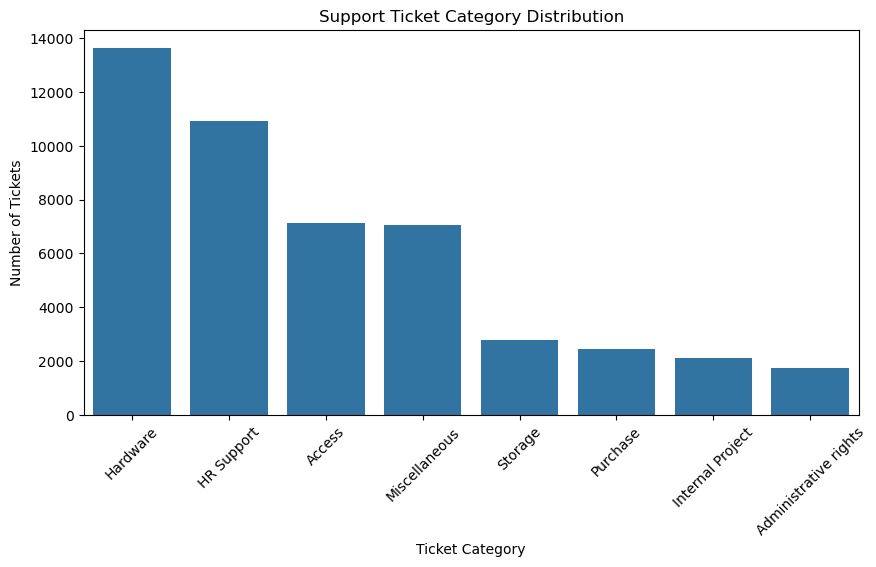

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="Topic_group",
    order=df["Topic_group"].value_counts().index
)
plt.title("Support Ticket Category Distribution")
plt.xlabel("Ticket Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

# 7. Feature Extraction using TF-IDF


In [10]:
X = df["Document"]
y = df["Topic_group"]

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (47837, 10000)


# 8. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 38269
Testing samples: 9568


# 9. Train Category Classification Model

In [12]:
category_model = LinearSVC()

category_model.fit(X_train, y_train)

print("Category classification model trained successfully!")

Category classification model trained successfully!


# 10. Evaluate Category Model

In [13]:
y_pred = category_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8538879598662207

Classification Report:

                       precision    recall  f1-score   support

               Access       0.90      0.89      0.90      1425
Administrative rights       0.85      0.71      0.77       352
           HR Support       0.86      0.86      0.86      2183
             Hardware       0.81      0.86      0.84      2724
     Internal Project       0.87      0.85      0.86       424
        Miscellaneous       0.81      0.81      0.81      1412
             Purchase       0.96      0.88      0.92       493
              Storage       0.93      0.87      0.90       555

             accuracy                           0.85      9568
            macro avg       0.87      0.84      0.86      9568
         weighted avg       0.86      0.85      0.85      9568



# 11. Confusion Matrix

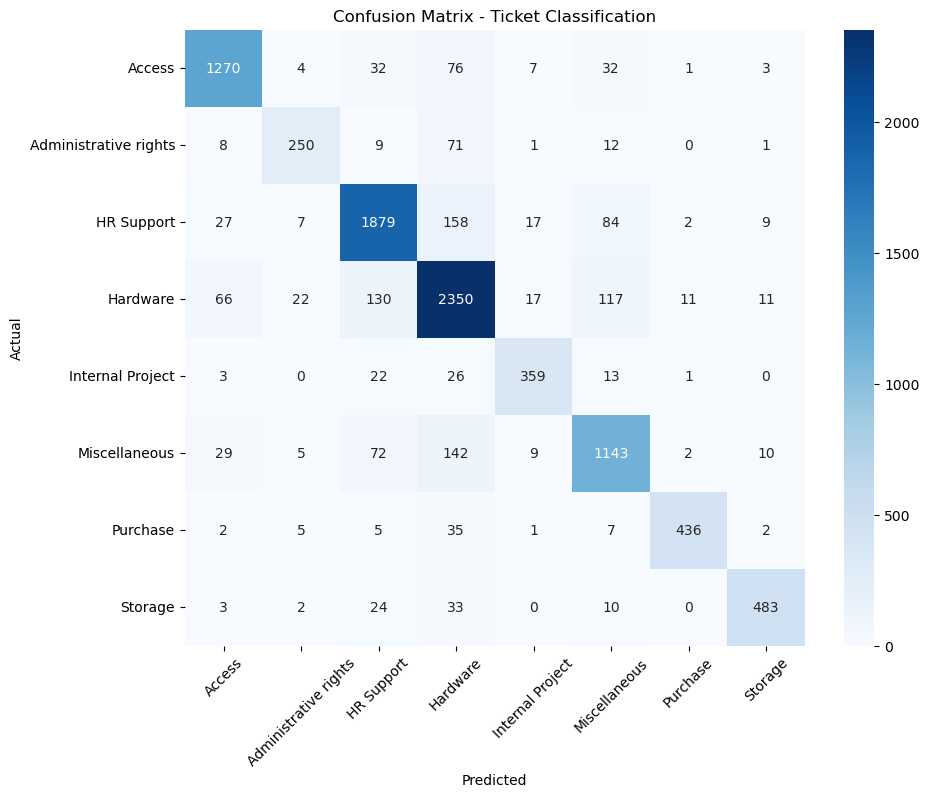

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=category_model.classes_,
    yticklabels=category_model.classes_
)

plt.title("Confusion Matrix - Ticket Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# 12. Create Priority Labels

In [ ]:
Write a program to output the square of * (stars) of size 4 (check the output below).

****
****
****
****

for i in range(4):
    print("****")



1 - 1
2 - 4
3 - 9
4 - 16
5 - 25


In [15]:
high_priority_keywords = [
    "server down",
    "system failure",
    "urgent",
    "critical",
    "cannot access",
    "data loss",
    "security breach"
]

medium_priority_keywords = [
    "slow",
    "delay",
    "password reset",
    "issue",
    "error",
    "unable"
]

def assign_priority(text):

    text = text.lower()

    for word in high_priority_keywords:
        if word in text:
            return "High"

    for word in medium_priority_keywords:
        if word in text:
            return "Medium"

    return "Low"

df["Priority"] = df["Document"].apply(assign_priority)

print(df["Priority"].value_counts())

Priority
Low       34799
Medium    11006
High       2032
Name: count, dtype: int64


# 13. Train Priority Prediction Model

In [16]:
X_priority = df["Document"]
y_priority = df["Priority"]

X_priority_tfidf = tfidf.fit_transform(X_priority)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_priority_tfidf,
    y_priority,
    test_size=0.2,
    random_state=42
)

priority_model = LogisticRegression(max_iter=200)

priority_model.fit(X_train_p, y_train_p)

print("Priority prediction model trained!")

Priority prediction model trained!


# 14. Evaluate Priority Model

In [17]:
priority_pred = priority_model.predict(X_test_p)

print("Priority Model Accuracy:")
print(accuracy_score(y_test_p, priority_pred))

print("\nClassification Report:\n")
print(classification_report(y_test_p, priority_pred))

Priority Model Accuracy:
0.9587165551839465

Classification Report:

              precision    recall  f1-score   support

        High       0.98      0.56      0.71       396
         Low       0.96      1.00      0.98      7037
      Medium       0.96      0.90      0.93      2135

    accuracy                           0.96      9568
   macro avg       0.96      0.82      0.87      9568
weighted avg       0.96      0.96      0.96      9568



# 15. Save Models

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
import joblib

# Create FINAL vectorizer for saving
final_tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit on complete dataset
final_X = final_tfidf.fit_transform(df["Document"])

# Retrain final category model
final_category_model = LinearSVC()
final_category_model.fit(final_X, df["Topic_group"])

# Retrain final priority model
final_priority_model = LogisticRegression(max_iter=200)
final_priority_model.fit(final_X, df["Priority"])

# Save everything
joblib.dump(final_category_model, "../models/category_model.pkl")
joblib.dump(final_priority_model, "../models/priority_model.pkl")
joblib.dump(final_tfidf, "../models/tfidf_vectorizer.pkl")

print("Final models saved successfully!")

Models saved successfully!
